# U-Net++

This is the main title of the notebook, indicating the use of the U-Net++ architecture for crack segmentation.

In [ ]:
!pip install -q segmentation-models-pytorch
!pip install -q albumentations
!pip install -q opencv-python

print("I love you so")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.0 MB/s eta 0:00:00
I love you so


This cell installs the necessary Python libraries: `segmentation_models_pytorch` for the U-Net++ model, `albumentations` for data augmentation, and `opencv-python` for image processing.

In [ ]:
# mount to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This cell mounts Google Drive to the Colab environment, allowing the notebook to access files stored in your Drive, such as datasets.

### Filter Blue Markers from Masks

To address the issue where the model incorrectly segments blue drawing markers as cracks, we'll implement a function to filter out these blue regions from the training masks. This function will identify blue pixels in the original image using HSV color space thresholding and then remove any overlapping positive regions from the corresponding mask. This ensures that the model learns to identify only actual cracks and not the markers.

This markdown cell explains the problem of blue markers being confused with cracks and introduces the solution: implementing a function to filter out these markers from the masks.

The `filter_blue_markers_from_mask` function uses the original image to identify blue regions, but it only modifies the masked image (the ground truth crack mask). It does not change the original image itself.

Here's the breakdown:

1. It takes the original image to detect where the blue markers are.
2. It creates a separate "blue marker mask" based on these detected blue regions.
3. It then uses this "blue marker mask" to effectively erase any corresponding pixels from the original crack mask that overlap with the identified blue markers.

So, in summary, it leverages the original image to refine the mask, ensuring the model isn't trained on blue marker artifacts within the mask.

In [ ]:
import cv2
import numpy as np

def filter_blue_markers_from_mask(image, mask):
    """
    Filters out regions from the mask that correspond to blue markers in the image.

    Args:
        image (np.array): The original RGB image.
        mask (np.array): The grayscale crack mask (binary, 0 or 1).

    Returns:
        np.array: The filtered grayscale crack mask.
    """
    # Convert RGB image to HSV for easier color thresholding
    hsv_image = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    # Define range for blue color in HSV (these values might need adjustment)
    # H: 90-130 (OpenCV range 0-179 for Hue)
    # S: 50-255 (Saturation)
    # V: 50-255 (Value/Brightness)
    lower_blue = np.array([90, 50, 50])
    upper_blue = np.array([130, 255, 255])

    # Threshold the HSV image to get only blue colors
    blue_mask_image = cv2.inRange(hsv_image, lower_blue, upper_blue)

    # Convert to a binary mask (0 or 1) for logical operations
    blue_mask_binary = (blue_mask_image > 0).astype(np.float32)

    # Remove any regions from the original 'mask' that overlap with 'blue_mask_binary'
    # Where original_mask is 1 AND blue_mask_binary is 1, set original_mask to 0.
    filtered_mask = mask * (1 - blue_mask_binary) # Element-wise multiplication

    return filtered_mask

This Python function `filter_blue_markers_from_mask` identifies blue regions in an image using HSV color space thresholding and removes corresponding areas from the crack mask. This prevents the model from learning to segment blue markers as cracks.

In [ ]:
# set data class
import cv2
import numpy as np
from torch.utils.data import Dataset

class CrackDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        mask = (mask > 127).astype(np.float32)

        # Apply blue marker filtering *before* any other transformations
        # This function was defined in a previous cell
        mask = filter_blue_markers_from_mask(image, mask)

        if self.transform:
            transformed = self.transform(
                image=image,
                mask=mask
            )
            image = transformed["image"]
            mask = transformed["mask"]

        image = image.transpose(2,0,1)

        return image.astype(np.float32), mask[None]

This cell defines the `CrackDataset` class, a custom PyTorch Dataset. It handles loading images and masks, applying the blue marker filter, and applying transformations (augmentation) to the data before it's fed to the model.

### Define data paths

Please update the `train_images_dir` and `train_masks_dir` variables with the actual paths to your training images and masks within your Google Drive. For example, if your images are in `/content/drive/MyDrive/dataset/train/images` and masks in `/content/drive/MyDrive/dataset/train/masks`, you would set those paths accordingly.

This markdown cell provides instructions for the user to update the paths to their training image and mask directories in Google Drive.

In [ ]:
import os
from torch.utils.data import DataLoader

# New base path for the dataset that includes images with markers
new_base_dataset_path = '/content/drive/MyDrive/Microscopic Crack Detection datasets/datasets/actual_images/datasets_v1_annotated_masked'

# Training data paths (using the 'train' split of the new dataset)
train_images_dir = os.path.join(new_base_dataset_path, 'train', 'images')
train_masks_dir = os.path.join(new_base_dataset_path, 'train', 'masks')

# Validation data paths (using the 'test' split of the new dataset for validation)
val_images_dir = os.path.join(new_base_dataset_path, 'test', 'images')
val_masks_dir = os.path.join(new_base_dataset_path, 'test', 'masks')

# Get all image and mask paths for training
train_image_paths = [os.path.join(train_images_dir, fname) for fname in sorted(os.listdir(train_images_dir))]
train_mask_paths = [os.path.join(train_masks_dir, fname) for fname in sorted(os.listdir(train_masks_dir))]

# Get all image and mask paths for validation
val_image_paths = [os.path.join(val_images_dir, fname) for fname in sorted(os.listdir(val_images_dir))]
val_mask_paths = [os.path.join(val_masks_dir, fname) for fname in sorted(os.listdir(val_masks_dir))]


print(f"Found {len(train_image_paths)} training images and {len(train_mask_paths)} training masks.")
print(f"Found {len(val_image_paths)} validation images and {len(val_mask_paths)} validation masks.")

Found 25 training images and 25 training masks.
Found 5 validation images and 5 validation masks.


### Visualize Blue Marker Filtering

Let's visualize the effect of the `filter_blue_markers_from_mask` function on a sample image and its mask to ensure it's working as expected before training.

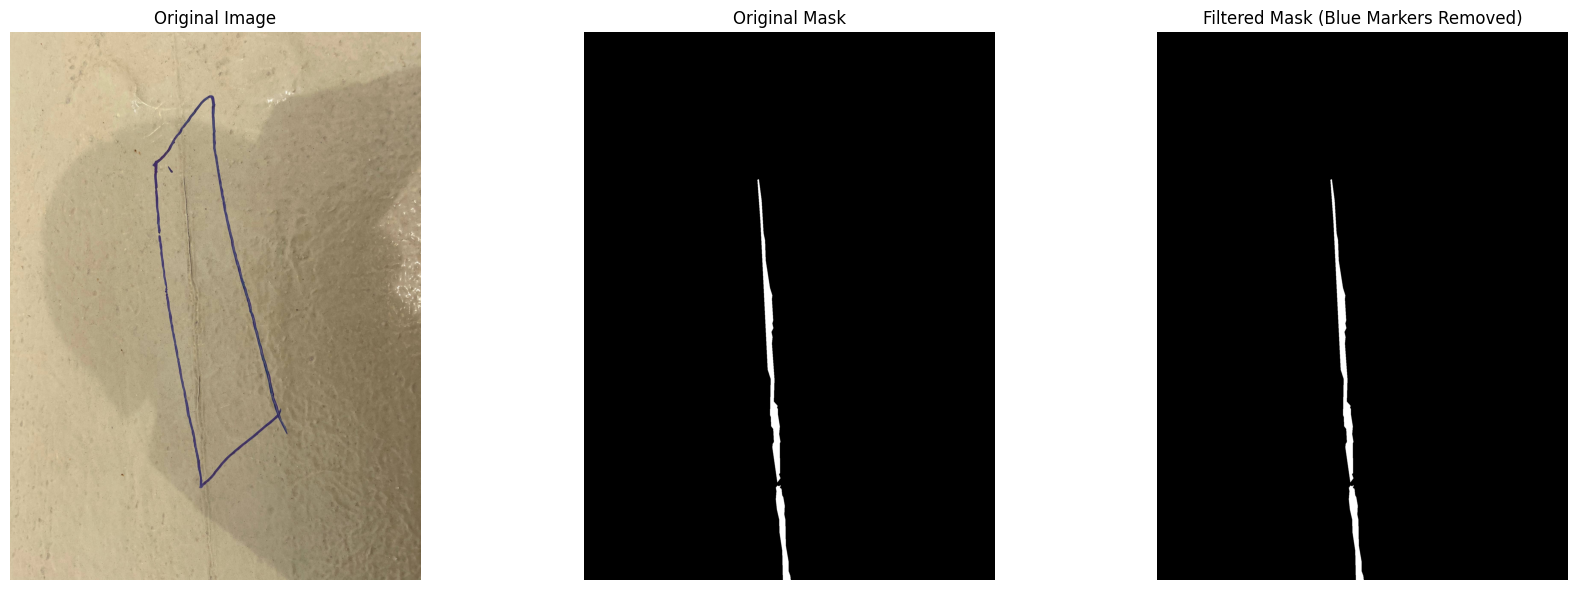

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Select a sample image and mask for visualization
sample_idx = 0  # You can change this index to view different samples
sample_image_path = train_image_paths[sample_idx]
sample_mask_path = train_mask_paths[sample_idx]

# Load the image and mask
sample_image = cv2.imread(sample_image_path)
sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)

sample_mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)
sample_mask_binary = (sample_mask > 127).astype(np.float32)

# Apply the blue marker filter
filtered_mask = filter_blue_markers_from_mask(sample_image, sample_mask_binary)

# Visualize the results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(sample_image)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(sample_mask_binary, cmap='gray')
axes[1].set_title('Original Mask')
axes[1].axis('off')

axes[2].imshow(filtered_mask, cmap='gray')
axes[2].set_title('Filtered Mask (Blue Markers Removed)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# augmentation
# for train
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),

    A.GaussNoise(p=0.3),
    A.Resize(1024, 1024) # Ensure all images are 1024x1024 after augmentation
])

# for test
val_transform = A.Compose([
    A.Resize(1024, 1024) # Ensure all images are 1024x1024 for validation
])

This cell defines data augmentation pipelines using `albumentations`. `train_transform` includes various augmentations like flips, rotations, brightness/contrast adjustments, and Gaussian noise to make the model more robust. `val_transform` is an empty transform for validation/testing, meaning no augmentations are applied.

This cell sets up the paths to the training images and masks within Google Drive, lists all files, and prints the count of images and masks found. It assumes the user has organized their dataset in the specified directory structure.

### Create Validation Dataset and DataLoader

In [ ]:
import os
from torch.utils.data import DataLoader

# Create the validation dataset and DataLoader
val_dataset = CrackDataset(
    image_paths=val_image_paths,
    mask_paths=val_mask_paths,
    transform=val_transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2, # Use the same batch size as training or adjust as needed
    shuffle=False, # No need to shuffle validation data
    num_workers=0
)

print(f"Validation DataLoader created with {len(val_loader)} batches.")

# Create the training dataset and DataLoader
train_dataset = CrackDataset(
    image_paths=train_image_paths,
    mask_paths=train_mask_paths,
    transform=train_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2, # Adjust as needed
    shuffle=True, # Shuffle training data
    num_workers=0
)

print(f"Training DataLoader created with {len(train_loader)} batches.")

Validation DataLoader created with 3 batches.
Training DataLoader created with 13 batches.


This cell instantiates the `CrackDataset` for training and creates a `DataLoader`. The `DataLoader` manages batching, shuffling, and loading data efficiently during the training process. The batch size is set to 8.

In [ ]:
# modelion
import segmentation_models_pytorch as smp

model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

This cell initializes the U-Net++ model from the `segmentation_models_pytorch` library. It uses `efficientnet-b0` as the encoder, pre-trained on `imagenet` for feature extraction, and is configured for binary segmentation (1 output class for cracks).

In [ ]:
# loss function
import torch
import torch.nn as nn

dice_loss = smp.losses.DiceLoss(
    mode='binary'
)

bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return (
        0.5 * dice_loss(pred, target)
        +
        0.5 * bce_loss(pred, target)
    )

This cell defines the loss function used for training. It's a hybrid loss, combining `DiceLoss` (good for imbalanced segmentation problems) and `BCEWithLogitsLoss` (a standard binary classification loss), both weighted equally.

In [ ]:
# optim
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

This cell sets up the optimizer for the model. `AdamW` is chosen for its effectiveness, with a learning rate of `1e-4` and a `weight_decay` of `1e-4` to help prevent overfitting.

In [ ]:
# Training Loop

from tqdm import tqdm
import torch

def train_one_epoch(
    model,
    loader,
    optimizer,
    device
):
    model.train()

    total_loss = 0

    for images, masks in tqdm(loader):

        # Directly move numpy arrays to tensor and then to device to avoid the UserWarning
        # Corrected: images and masks are already tensors from DataLoader
        images = images.float().to(device)
        masks = masks.float().to(device)

        optimizer.zero_grad()

        preds = model(images)

        loss = loss_fn(
            preds,
            masks
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

This cell defines the `train_one_epoch` function, which performs a single pass over the entire training dataset. It handles moving data to the GPU, calculating the loss, performing backpropagation, and updating model weights.

In [ ]:
# volidatio dice

def dice_score(preds, targets):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    intersection = (
        preds * targets
    ).sum()

    union = (
        preds.sum()
        +
        targets.sum()
    )

    return (
        2.0 * intersection + 1e-7
    ) / (
        union + 1e-7
    )

This cell defines the `dice_score` function, which is a common metric for evaluating segmentation models. It measures the overlap between the predicted mask and the ground truth mask, providing an indication of segmentation accuracy.

In [ ]:
# training

device = "cuda"

model = model.to(device)

best_dice = 0

def validate_one_epoch(
    model,
    loader,
    device
):
    model.eval()

    total_dice = 0

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validating"):
            images = images.float().to(device)
            masks = masks.float().to(device)

            preds = model(images)

            dice = dice_score(
                preds,
                masks
            )
            total_dice += dice.item()
    return total_dice / len(loader)

for epoch in range(50):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device
    )

    val_dice = validate_one_epoch(
        model,
        val_loader,
        device
    )

    print(
        f"Epoch {epoch}"
        f" Loss {train_loss:.4f}"
        f" Val Dice {val_dice:.4f}"
    )

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(
            model.state_dict(),
            "best_model.pt" # Save best model based on validation Dice score
        )
        print(f"Saved best model with Dice: {best_dice:.4f}")

    torch.save(
        model.state_dict(),
        "latest.pt"
    )

Validating: 100%|██████████| 3/3 [00:11<00:00,  3.93s/it]


Epoch 0 Loss 0.9218 Val Dice 0.0181
Saved best model with Dice: 0.0181


Validating: 100%|██████████| 3/3 [00:01<00:00,  2.90it/s]


Epoch 1 Loss 0.8755 Val Dice 0.0064


Validating: 100%|██████████| 3/3 [00:01<00:00,  2.42it/s]


...

Epoch 47 Loss 0.5029 Val Dice 0.4837


Validating: 100%|██████████| 3/3 [00:01<00:00,  2.83it/s]


Epoch 48 Loss 0.5016 Val Dice 0.5578
Saved best model with Dice: 0.5578


Validating: 100%|██████████| 3/3 [00:01<00:00,  2.76it/s]

Epoch 49 Loss 0.4944 Val Dice 0.5623
Saved best model with Dice: 0.5623


This cell contains the main training loop. It iterates for a specified number of epochs (50), calls `train_one_epoch` for each epoch, prints the training loss, and saves the model's weights to a file named `latest.pt` after each epoch.

This markdown cell indicates the beginning of the section for testing the trained model on actual test images.

Test on Actual Test Images

Found 5 test images and 5 test masks.
Test DataLoader created with 5 batches.

--- Visualizing Predictions ---


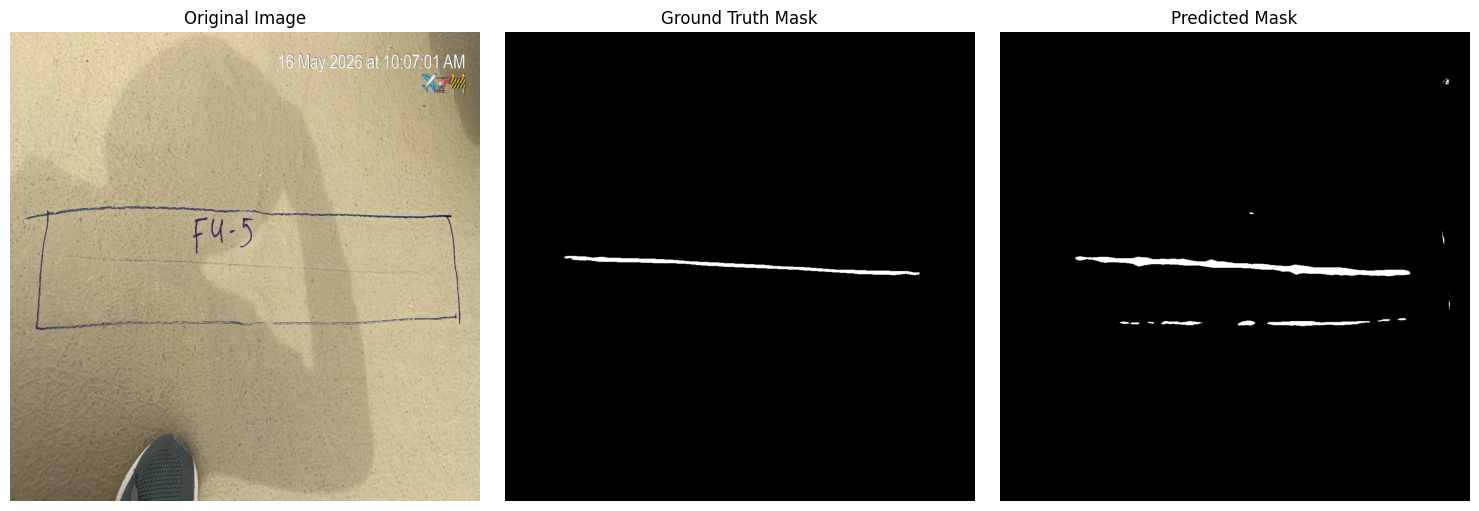

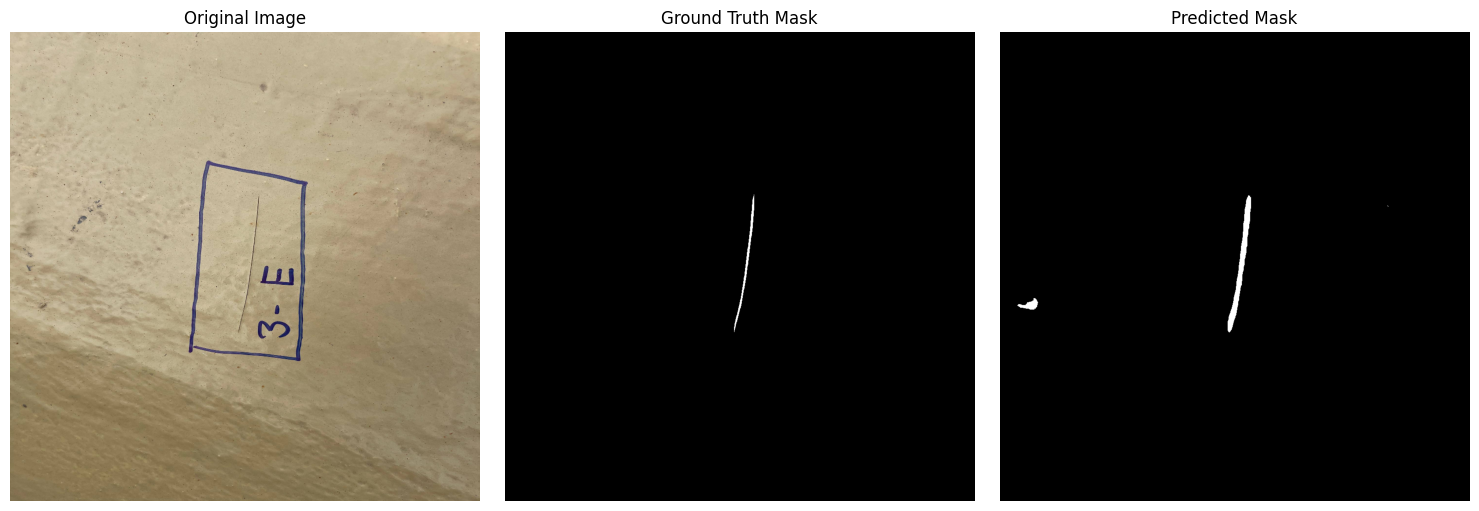

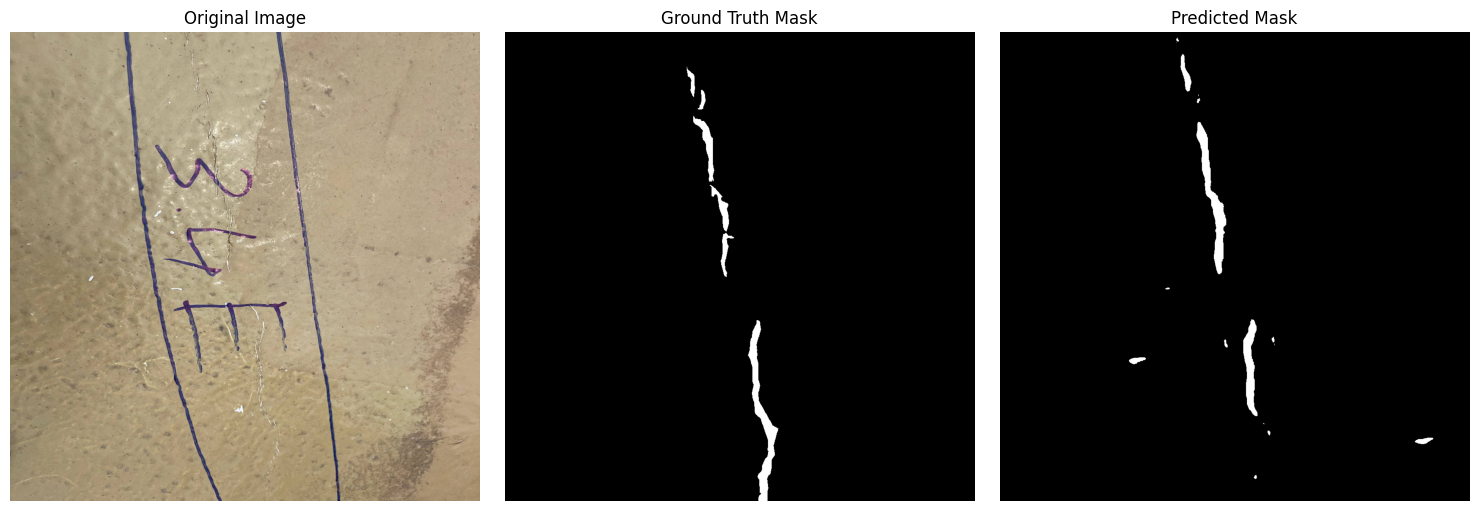

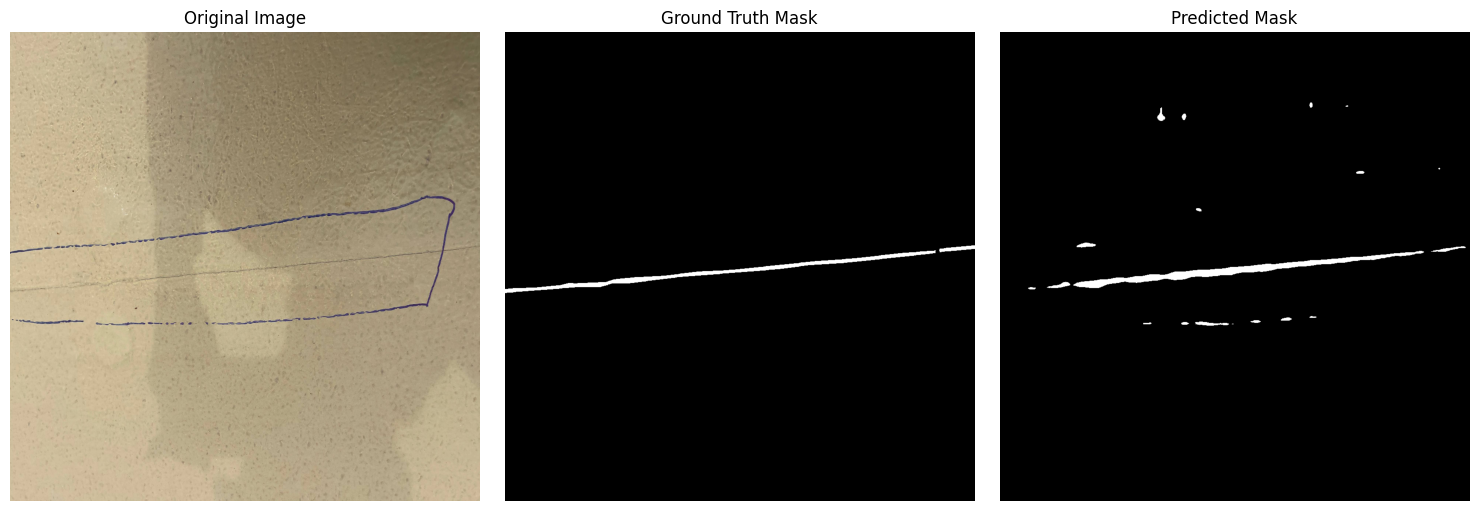

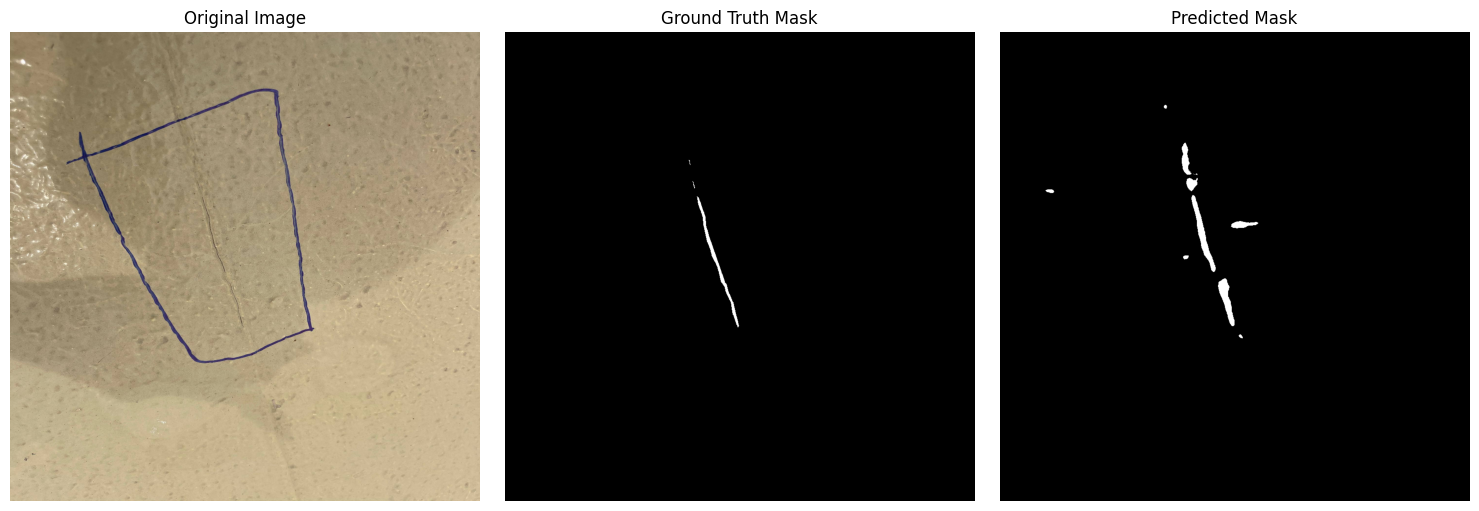

In [ ]:
# Test loop and visualization
import os
import matplotlib.pyplot as plt
import torch
import numpy as np

device = "cuda"

model = model.to(device)

# --- 1. Define Test Data Paths ---
# IMPORTANT: These paths now point to the 'test' split of the new dataset with markers
test_images_dir = '/content/drive/MyDrive/Microscopic Crack Detection datasets/datasets/actual_images/datasets_v1_annotated_masked/test/images'
test_masks_dir = '/content/drive/MyDrive/Microscopic Crack Detection datasets/datasets/actual_images/datasets_v1_annotated_masked/test/masks'

# Get all image and mask paths for testing
test_image_paths = [os.path.join(test_images_dir, fname) for fname in sorted(os.listdir(test_images_dir))]
test_mask_paths = [os.path.join(test_masks_dir, fname) for fname in sorted(os.listdir(test_masks_dir))]

print(f"Found {len(test_image_paths)} test images and {len(test_mask_paths)} test masks.")

# --- 2. Create Test Dataset and DataLoader ---
test_dataset = CrackDataset(
    image_paths=test_image_paths,
    mask_paths=test_mask_paths,
    transform=val_transform # Use val_transform (no augmentations)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1, # Typically batch size 1 for inference/visualization
    shuffle=False,
    num_workers=0 # No multiprocessing needed for single image inference
)

print(f"Test DataLoader created with {len(test_loader)} batches.")

# --- 3. Load the best model weights ---
# Ensure the model is in evaluation mode
model.load_state_dict(torch.load('/content/v3_best.pt')) # Load the best trained weights
model.eval() # Set model to evaluation mode
model.to(device)

# --- 4. Prediction and Visualization Function ---
def predict_and_plot(model, dataloader, device, num_samples=5):
    model.eval()
    samples_processed = 0
    with torch.no_grad():
        for i, (images, masks) in enumerate(dataloader):
            if samples_processed >= num_samples:
                break

            # Move data to device
            original_image = images.numpy().squeeze() # For plotting, get original shape
            ground_truth_mask = masks.numpy().squeeze()

            images = torch.from_numpy(images.numpy()).float().to(device)
            masks = torch.from_numpy(masks.numpy()).float().to(device)

            # Make prediction
            preds = model(images)
            predicted_mask = torch.sigmoid(preds).cpu().numpy().squeeze()
            predicted_mask = (predicted_mask > 0.5).astype(np.float32) # Binarize

            # Plotting
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))

            # Original Image
            # Permute back to (H, W, C) for matplotlib if it's (C, H, W)
            if original_image.shape[0] == 3 or original_image.shape[0] == 1: # Check if it's C, H, W
                 original_image = np.transpose(original_image, (1, 2, 0))

            # If it's a single channel image, convert to 2D for imshow
            if original_image.shape[-1] == 1:
                original_image = original_image.squeeze(axis=-1)

            axes[0].imshow(original_image.astype(np.uint8))
            axes[0].set_title('Original Image')
            axes[0].axis('off')

            # Ground Truth Mask
            axes[1].imshow(ground_truth_mask, cmap='gray')
            axes[1].set_title('Ground Truth Mask')
            axes[1].axis('off')

            # Predicted Mask
            axes[2].imshow(predicted_mask, cmap='gray')
            axes[2].set_title('Predicted Mask')
            axes[2].axis('off')

            plt.tight_layout()
            plt.show()
            samples_processed += 1

# Call the function to predict and plot for a few samples
print("\n--- Visualizing Predictions ---")
predict_and_plot(model, test_loader, device, num_samples=5)


This cell sets up the test data paths, creates a `CrackDataset` and `DataLoader` for testing, loads the trained model weights, and then defines and calls a `predict_and_plot` function to visualize the model's predictions on a few test images alongside their ground truth masks.

Found 5 images for tiled testing.

--- Performing Tiled Predictions and Visualizations ---


Predicting tiles for photo_10_2026-05-26_10-16-13_jpg.rf.sip1yGpVYT0FCVvRq4K2.jpg: 100%|██████████| 3/3 [00:00<00:00,  3.10it/s]


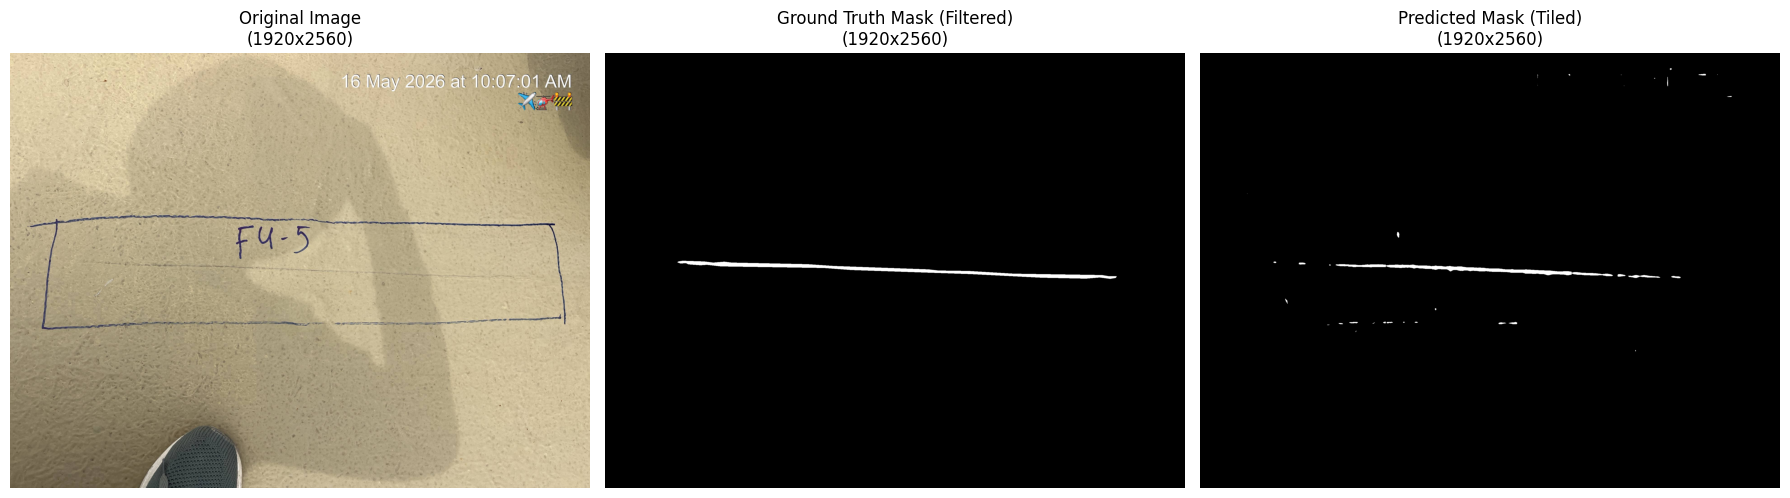

Predicting tiles for photo_11_2026-05-26_10-16-13_jpg.rf.5QZqtp3lIfc6egeBwCUT.jpg: 100%|██████████| 3/3 [00:00<00:00,  3.10it/s]


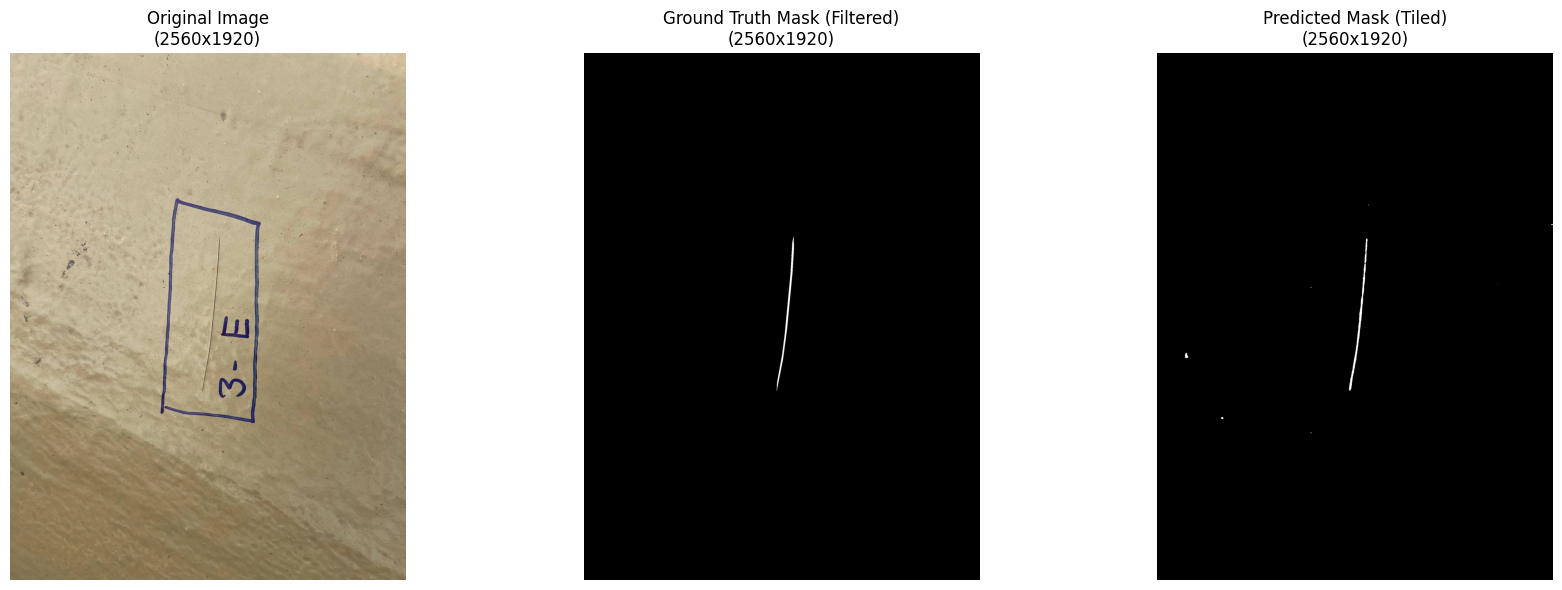

Predicting tiles for photo_12_2026-05-26_10-16-13_jpg.rf.iByAy8XuD1SEAfOJZGwL.jpg: 100%|██████████| 3/3 [00:00<00:00,  3.04it/s]


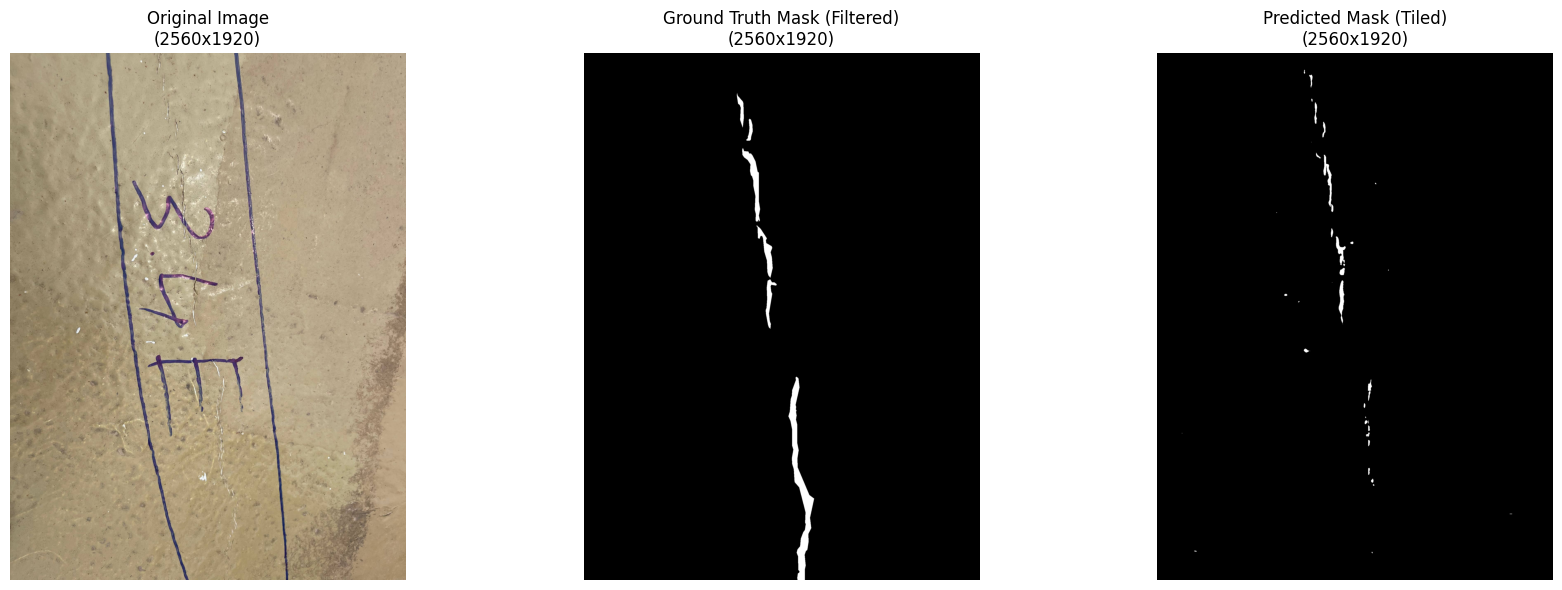

In [ ]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import math
from tqdm import tqdm # Assuming tqdm is already imported from previous cells

# Define tiling parameters
TILE_SIZE = 1024
OVERLAP_RATIO = 0.2
OVERLAP_PX = int(TILE_SIZE * OVERLAP_RATIO)
STRIDE = TILE_SIZE - OVERLAP_PX

# --- Tiling Function ---
def get_tiles(image, tile_size, overlap_px):
    """
    Extracts overlapping tiles from a large image.
    Returns a list of (tile, (row_start, col_start))
    """
    h, w, c = image.shape
    stride = tile_size - overlap_px

    # Calculate padding needed
    num_steps_h = max(1, math.ceil((h - overlap_px) / stride)) if h > tile_size else 1
    num_steps_w = max(1, math.ceil((w - overlap_px) / stride)) if w > tile_size else 1

    target_h = (num_steps_h - 1) * stride + tile_size
    target_w = (num_steps_w - 1) * stride + tile_size

    pad_h = target_h - h
    pad_w = target_w - w

    padded_image = np.pad(image, ((0, pad_h), (0, pad_w), (0, 0)), mode='reflect')

    padded_h, padded_w, _ = padded_image.shape
    tiles = []
    coords = []

    for r in range(num_steps_h):
        for c in range(num_steps_w):
            r_start = r * stride
            c_start = c * stride
            tile = padded_image[r_start : r_start + tile_size, c_start : c_start + tile_size]
            tiles.append(tile)
            coords.append((r_start, c_start))

    return tiles, coords, padded_image.shape, (h, w) # Return original unpadded shape


# --- Reconstruction Function ---
def reconstruct_image(predicted_tiles, tile_coords, original_padded_shape, original_unpadded_shape, tile_size, overlap_px):
    """
    Reconstructs the full prediction mask from predicted tiles, handling overlaps by averaging.
    `predicted_tiles` is a list of numpy arrays (predicted masks for each tile).
    `tile_coords` is a list of (row_start, col_start) for each tile.
    `original_padded_shape` is (padded_h, padded_w, channels)
    `original_unpadded_shape` is (h,w) for the original image before padding
    """
    padded_h, padded_w, _ = original_padded_shape
    reconstructed_mask = np.zeros((padded_h, padded_w), dtype=np.float32)
    overlap_counts = np.zeros((padded_h, padded_w), dtype=np.int32)

    for i, tile_mask in enumerate(predicted_tiles):
        r_start, c_start = tile_coords[i]
        # Squeeze tile_mask to ensure it's 2D if it came as (1, H, W)
        reconstructed_mask[r_start : r_start + tile_size, c_start : c_start + tile_size] += tile_mask.squeeze()
        overlap_counts[r_start : r_start + tile_size, c_start : c_start + tile_size] += 1

    # Handle division by zero for areas not covered (shouldn't happen with proper tiling)
    overlap_counts[overlap_counts == 0] = 1
    reconstructed_mask /= overlap_counts

    # Crop back to original unpadded dimensions
    unpadded_h, unpadded_w = original_unpadded_shape
    reconstructed_mask = reconstructed_mask[:unpadded_h, :unpadded_w]

    return reconstructed_mask

# --- Custom Dataset for a single large image for tiling ---
class TiledImageDataset(Dataset):
    def __init__(self, image_path, transform=None, tile_size=1024, overlap_ratio=0.2):
        self.image_path = image_path
        self.transform = transform
        self.tile_size = tile_size
        self.overlap_ratio = overlap_ratio
        self.overlap_px = int(tile_size * overlap_ratio)
        self.stride = tile_size - self.overlap_px

        self.image = cv2.imread(self.image_path)
        self.image = cv2.cvtColor(self.image, cv2.COLOR_BGR2RGB)

        self.tiles, self.coords, self.padded_shape, self.original_unpadded_shape = get_tiles(self.image, self.tile_size, self.overlap_px)

    def __len__(self):
        return len(self.tiles)

    def __getitem__(self, idx):
        tile = self.tiles[idx]
        coord = self.coords[idx]

        if self.transform:
            transformed = self.transform(image=tile)
            tile = transformed["image"]

        # Ensure tile is C, H, W and float32
        tile = tile.transpose(2,0,1).astype(np.float32)

        return tile, coord # Return tile and its original coordinates


# --- Modified Prediction and Plotting Function for Tiled Inference ---
def predict_and_plot_tiled(model, image_path, mask_path, device, val_transform, tile_size=1024, overlap_ratio=0.2):
    model.eval()
    with torch.no_grad():
        # Create dataset for a single large image to get original image and tiles
        tiled_dataset = TiledImageDataset(image_path, val_transform, tile_size, overlap_ratio)
        tiled_dataloader = DataLoader(tiled_dataset, batch_size=4, shuffle=False, num_workers=0) # Batch processing for tiles

        # Load original ground truth mask if available
        ground_truth_mask = None
        if os.path.exists(mask_path):
            ground_truth_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if ground_truth_mask is not None:
                ground_truth_mask = (ground_truth_mask > 127).astype(np.float32)
                # Apply blue marker filtering to the ground truth mask for consistency
                ground_truth_mask = filter_blue_markers_from_mask(tiled_dataset.image, ground_truth_mask)
            else:
                print(f"Warning: Could not read mask file at {mask_path}.")
        else:
            print(f"Warning: Ground truth mask not found at {mask_path}. Skipping ground truth display.")


        predicted_tile_masks = []
        tile_coords = []

        # Predict on tiles
        for tiles_batch, coords_batch in tqdm(tiled_dataloader, desc=f"Predicting tiles for {os.path.basename(image_path)}"):
            tiles_batch = tiles_batch.to(device)
            preds_batch = model(tiles_batch)
            preds_batch = torch.sigmoid(preds_batch).cpu().numpy()
            predicted_tile_masks.extend(preds_batch)
            # coords_batch is a tuple of tensors (r_coords_tensor, c_coords_tensor), so iterate with zip
            tile_coords.extend([(r.item(), c.item()) for r, c in zip(*coords_batch)])

        # Reconstruct full mask
        reconstructed_prediction = reconstruct_image(
            predicted_tile_masks,
            tile_coords,
            tiled_dataset.padded_shape,
            tiled_dataset.original_unpadded_shape,
            tile_size,
            tiled_dataset.overlap_px
        )

        reconstructed_prediction = (reconstructed_prediction > 0.5).astype(np.float32) # Binarize final mask

        # Display results
        fig, axes = plt.subplots(1, 3 if ground_truth_mask is not None else 2, figsize=(18, 6))

        # Original Image
        original_img = tiled_dataset.image # Use the original unpadded image
        axes[0].imshow(original_img)
        axes[0].set_title(f'Original Image\n({original_img.shape[0]}x{original_img.shape[1]})')
        axes[0].axis('off')

        if ground_truth_mask is not None:
            # Ground Truth Mask
            axes[1].imshow(ground_truth_mask, cmap='gray')
            axes[1].set_title(f'Ground Truth Mask (Filtered)\n({ground_truth_mask.shape[0]}x{ground_truth_mask.shape[1]})')
            axes[1].axis('off')

            # Predicted Mask
            axes[2].imshow(reconstructed_prediction, cmap='gray')
            axes[2].set_title(f'Predicted Mask (Tiled)\n({reconstructed_prediction.shape[0]}x{reconstructed_prediction.shape[1]})')
            axes[2].axis('off')
        else:
            # Predicted Mask (if no ground truth)
            axes[1].imshow(reconstructed_prediction, cmap='gray')
            axes[1].set_title(f'Predicted Mask (Tiled)\n({reconstructed_prediction.shape[0]}x{reconstructed_prediction.shape[1]})')
            axes[1].axis('off')


        plt.tight_layout()
        plt.show()


# --- Main execution block for tiled inference ---
# Update test paths based on user's input
new_base_test_dir = '/content/drive/MyDrive/Microscopic Crack Detection datasets/datasets/actual_images/datasets_v1_annotated_masked'
new_test_images_dir = os.path.join(new_base_test_dir, 'test', 'images') # Corrected path for images
new_test_masks_dir = os.path.join(new_base_test_dir, 'test', 'masks')   # Corrected path for masks

if not os.path.exists(new_test_images_dir):
    print(f"Error: Image directory not found at {new_test_images_dir}. Please verify the path.")
else:
    # Get all image paths from the new directory
    new_test_image_paths = [os.path.join(new_test_images_dir, fname) for fname in sorted(os.listdir(new_test_images_dir)) if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

    if not new_test_image_paths:
        print(f"No images found in {new_test_images_dir}. Please check the path and content.")
    else:
        print(f"Found {len(new_test_image_paths)} images for tiled testing.")

        # Load the trained model (assuming 'model' and 'device' are already defined in the notebook)
        # Ensure model is on the correct device and in evaluation mode
        model.load_state_dict(torch.load('latest.pt')) # Load the latest trained weights
        model.eval() # Set model to evaluation mode
        model.to(device)

        print("\n--- Performing Tiled Predictions and Visualizations ---")
        num_samples_to_plot = 3 # You can adjust this number to visualize more or fewer samples

        # Iterate through the images and apply tiled prediction
        for i, image_path in enumerate(new_test_image_paths):
            if i >= num_samples_to_plot:
                break

            # Construct corresponding mask path (assuming same filename for mask)
            image_filename = os.path.basename(image_path)
            mask_path = os.path.join(new_test_masks_dir, image_filename)

            predict_and_plot_tiled(model, image_path, mask_path, device, val_transform, TILE_SIZE, OVERLAP_RATIO)